# Simple Simulation of the OU process

So for the standard OU process used in our report we have the transition probability being exactly $$Z_t^{\beta} | Z_s^{\beta} = N \left ( e^{- \beta (t -s)Z_s^{\beta}}, \frac{1 - e^{-2 \beta(t-s)}}{2 \beta} \right ) $$
 So we use the exact discretization:
 $$Z_{t + \Delta t} = e^{- \beta \Delta t}Z_t + \frac{1 - e^{-2 \beta(\Delta t)}}{2 \beta} W$$
 where $ W \sim N(0,1)$

 We can start the process at $Z_0 = 0$..

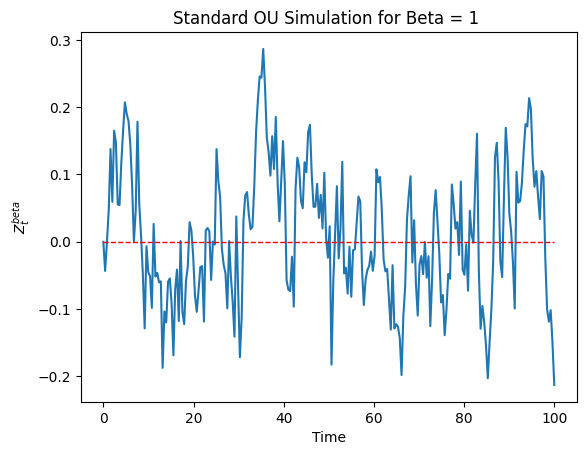

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 252
t = 100
dt = t/n
times = np.linspace(0, t, n)
beta = 1

W = np.random.normal(0, dt, n)


Z = np.zeros(n)
Z[0] = 0 # start at z_0 = 0 which can be changed to start from any point
for i in range(1, n):
    Z[i] = np.exp(-beta * dt) * Z[i-1] + (1 - np.exp(-beta * dt))/ (2* beta) * W[i]
    

plt.plot(times, Z)
plt.title(f"Standard OU Simulation for Beta = {beta} ")
plt.hlines(0, color='r', linestyle='--', linewidth=1, xmin=0, xmax=t)
plt.xlabel("Time")
plt.ylabel("$Z^{beta}_t$")
plt.show()

# A More General OU Simulation

We will next generalise the above simulation in two ways.

- First of all we will remove the assmuption that it starts at the origin and have it start at $-\infty$ to make the process stationary.

- Next we will be simulating $n$ correlated OU processes - this is what we will later need for fBm. To do this we account for $Z_0^{\beta_i} = \int_{-\infty}^0 e^{\beta_i u} dB_u$ for each $i = 1 , \dots, n$. Note that each $Z_0^{\beta_i} \sim N(0, \frac1{2 \beta})$ with $cov(Z_0^{\beta_i}, Z_0^{\beta_j}) = \frac1{\beta_i + \beta_j}$. Thus we can simply use the Cholesky method to simulate this multivariate Gaussian.

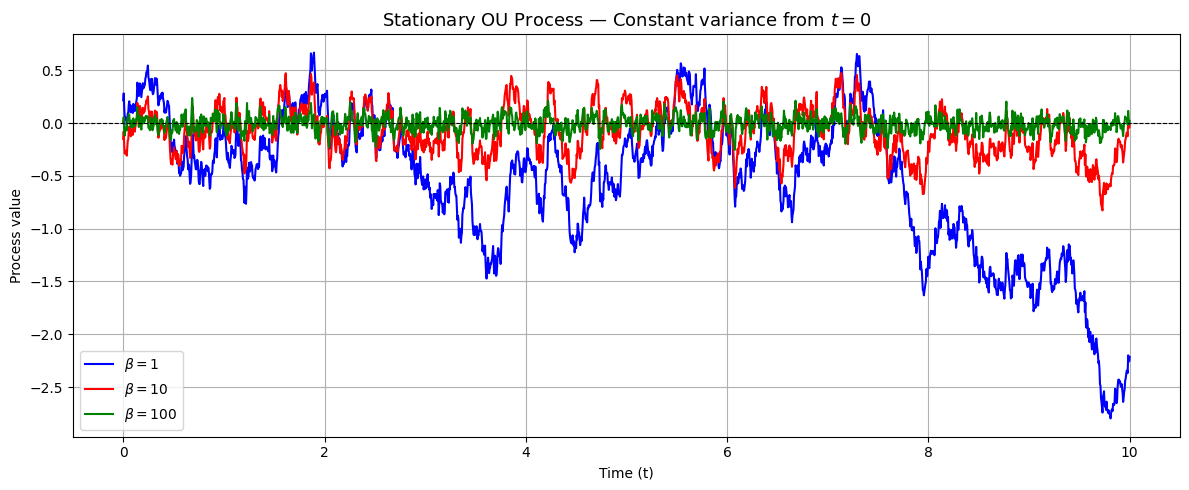

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_OU_paths(beta, T, n_steps, M, rng, stationary_start=True):
    """
    Simulate M paths of the OU process for each rate in `beta`, jointly,
    all driven by the SAME scalar Brownian increments per path.

    Returns array of shape (M, n_steps+1, len(beta)).
    """
    beta = np.asarray(beta)
    
    dt = T / n_steps
    decay = np.exp(-beta * dt)
    scale = np.sqrt((1 - np.exp(-2 * beta * dt)) / (2 * beta))

    Z = np.zeros((M, len(beta)))
    if stationary_start:
        Gamma = 1.0 / (beta[:, None] + beta[None, :])
        L = np.linalg.cholesky(Gamma + 1e-12 * np.eye(len(beta)))
        Z = rng.normal(size=(M, len(beta))) @ L.T

    Z_path = np.zeros((M, n_steps + 1, len(beta)))
    Z_path[:, 0, :] = Z

    for i in range(n_steps):
        noise = rng.normal(size=M)
        Z = decay[None, :] * Z + scale[None, :] * noise[:, None]
        Z_path[:, i + 1, :] = Z

    return Z_path

# ---------- Parameters ----------
T = 10
n_steps = 2000
betas = [1, 10, 100]      # can be a list – the function now converts it
M = 1
rng = np.random.default_rng(42)

# Simulate stationary fBm only
paths = simulate_OU_paths(betas, T, n_steps, M, rng, stationary_start=True)[0]  # shape: (steps, 3)

t = np.linspace(0, T, n_steps + 1)
colors = ['blue', 'red', 'green']
labels = [f'$\\beta = {b}$' for b in betas]

# ---------- Plot ----------
plt.figure(figsize=(12, 5))
for i in range(len(betas)):
    plt.plot(t, paths[:, i], color=colors[i], label=labels[i])

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Stationary OU Process — Constant variance from $t=0$', fontsize=13)
plt.xlabel('Time (t)')
plt.ylabel('Process value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# The Fractional Kernel Approximation

The key part of the OU represntation for fBm uses fact that
$$(t-u)^{H - \frac12} = \frac{1}{\Gamma(\frac12 - H)} \int_0^{\infty} \beta^{-\frac12 - H} e^{-(t-u)} d \beta$$
Hence we can approximate our kernel $$ K(t,u) = (t - u)^{H - \frac12} \approx \sum_i w_j e^{-(t-u) \beta_j} $$ 

We choose a geometric quadrature $\beta_j = r^{j}$ for $r \in (1,2)$ (accounts for the fact that larger $\beta$ is faster mean reverting so shorter time scale ).

So under this discretization we have $$w_j = \frac1{\Gamma \left (\frac12 - H \right) } \int_{r^{j - 1}}^{r^j} x^{-\frac12 - H} dx$$ Hence $$w_j = \frac1{\Gamma(\frac12 - H)} r^{j - 1(\frac12 - H)} \left [ \frac{r^{\frac12 - H} - 1}{\frac12 - H} \right ] $$

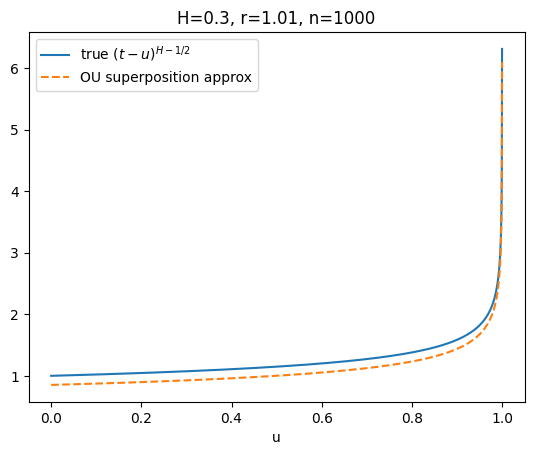

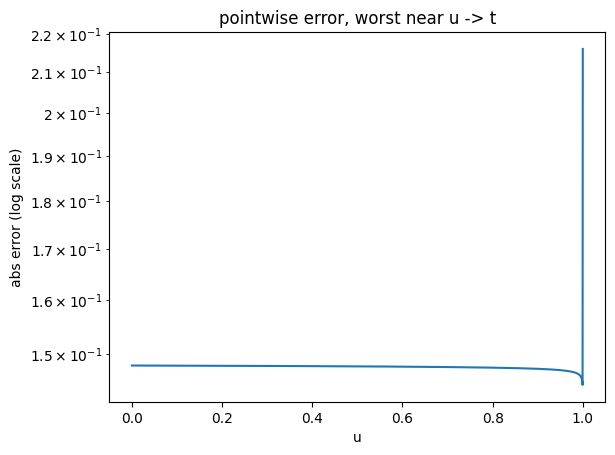

In [31]:
import numpy as np
from scipy.special import gamma
import matplotlib.pyplot as plt

def OU_weights(H, r, n):
    """
    Nodes beta_j = r^{j-1} and weights w_j for j = -n+1,...,n,
    approximating (t-u)^{H-1/2} = (1/Gamma(1/2-H)) * int_0^inf x^{-H-1/2} e^{-x(t-u)} dx.
    """
    a = H + 0.5
    j = np.arange(-n + 1, n + 1)          # 2n values: -n+1, ..., n
    beta = r**(j - 1)
    weights = (1/gamma(0.5 - H)) * r**((1 - a)*(j - 1)) * (r**(1 - a) - 1)/(1 - a)
    return beta, weights

def kernel_true(t, u, H):
    return (t - u) ** (H - 0.5)

def kernel_approx(t, u, H, n, r):
    beta, weights = OU_weights(H, r, n)  
    du = (t - u)[:, None]                
    return np.sum(weights[None, :] * np.exp(-beta[None, :] * du), axis=1)

# --- example ---
alpha = 0.3
t = 1.0
r = 1.01
n = 1000

u = np.linspace(0, t - 1e-4, 2000)
f_true = kernel_true(t, u, alpha)
f_hat  = kernel_approx(t, u, alpha, n, r)
err = np.abs(f_true - f_hat)

plt.figure()
plt.plot(u, f_true, label="true $(t-u)^{H-1/2}$")
plt.plot(u, f_hat, '--', label="OU superposition approx")
plt.legend(); plt.xlabel("u"); plt.title(f"H={alpha}, r={r}, n={n}")

plt.figure()
plt.semilogy(u, err)
plt.xlabel("u"); plt.ylabel("abs error (log scale)")
plt.title("pointwise error, worst near u -> t")
plt.show()
    
    
    

    

# Simulating fBm using OU

We only simulate the $H < \frac12$ here for simplicity. Note that for $H < \frac12$:
$$B_t^H= \bar{c}_H \int_0^{\infty} \beta^{-1 / 2-H}\left(Z_t^\beta-Z_0^\beta\right) d \beta$$
So we discretize this using
$$B_t^{H, n} = \sum_{j = 0}^n w_j (Z^{\beta_i}_t - {Z^{\beta_i}_0})$$

Which allows us to use the same weights as from the previous markdown. Thus in order to simulate paths in this way we will employ the weights from the previous markdown and use the same method for generating the values of $Z_t^{\beta}$ from the first (top) markdown.

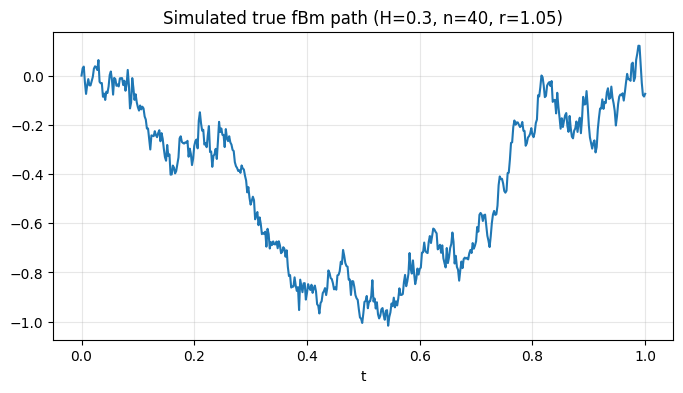

In [49]:
def simulate_fBm_paths(H, r, n, T, n_steps, M, rng):
    """
    Simulate M fBm sample paths using the existing OU and weight machinery:
    B_t^{H,n} = sum_j w_j * (Z_t^{beta_j} - Z_0^{beta_j})

    Uses simulate_OU_paths (stationary start, correlated across beta_j)
    and OU_weights (nodes + quadrature weights) directly.
    """
    beta, w = OU_weights(H, r, n)

    # shape (M, n_steps+1, 2n) -- stationary_start=True gives correct correlated Z_0
    Z_path = simulate_OU_paths(beta, T, n_steps, M, rng, stationary_start=True)

    B_raw = Z_path @ w              # weighted sum over beta axis -> (M, n_steps+1)
    return B_raw - B_raw[:, [0]]    # subtract each path's own Z_0-contribution

#----------------------------------------------------------------------
#visualtion 

H = 0.3
r = 1.05
n = 40
T = 1.0
n_steps = 500

rng = np.random.default_rng(1)
times = np.linspace(0, T, n_steps + 1)

B_all = simulate_fBm_paths(H, r, n, T, n_steps, M=1, rng=rng)
B = B_all[0]

plt.figure(figsize=(8, 4))
plt.plot(times, B)
plt.title(f"Simulated true fBm path (H={H}, n={n}, r={r})")
plt.xlabel("t"); plt.grid(alpha=0.3)
plt.show()